In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import rand_score, adjusted_rand_score

In [3]:
merged = pd.read_csv("../data/merged.csv")
print(merged.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures_mat', 'schoolsup', 'famsup', 'paid_mat', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences_mat', 'G1_mat', 'G2_mat',
       'G3_mat', 'failures_por', 'paid_por', 'absences_por', 'G1_por',
       'G2_por', 'G3_por', 'reussite_mat', 'reussite_por', 'reussite'],
      dtype='object')


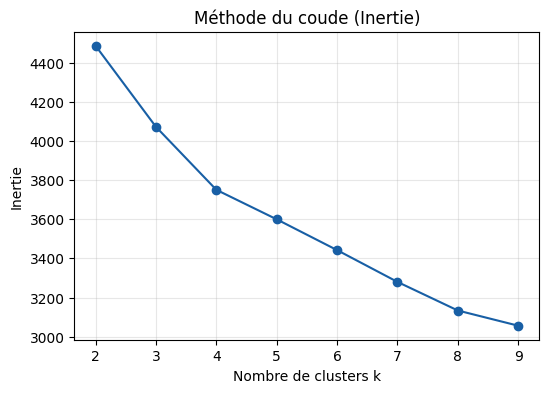

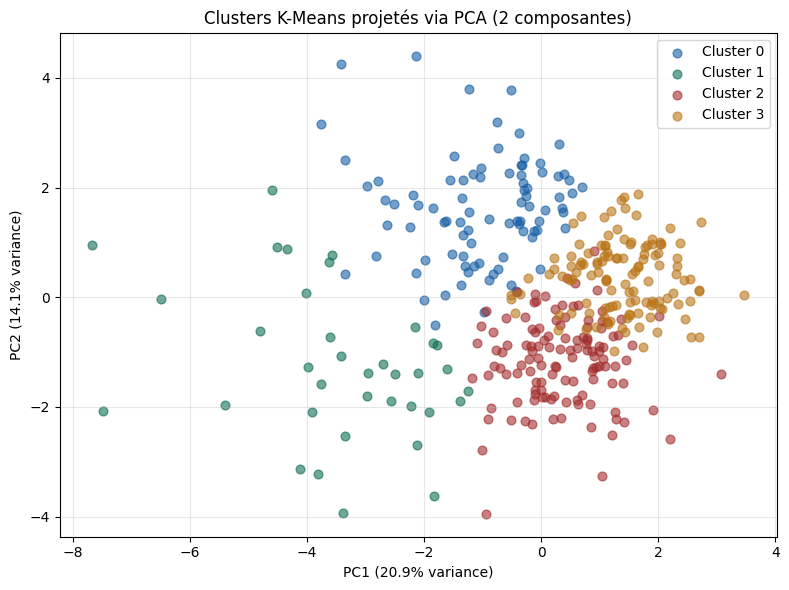


Profil moyen par cluster :
         studytime  Dalc  Walc  goout  freetime  Medu  Fedu  famrel  health  absences_mat  G3_mat  G3_por  failures_mat  failures_por
cluster                                                                                                                              
0             1.78  2.38  3.73   4.01      3.68  3.22  2.99    3.70    3.68          9.10   10.16   11.75          0.20          0.06
1             1.42  1.92  3.03   3.47      3.44  1.83  1.61    3.78    4.11          4.72    6.19    8.61          1.92          1.11
2             2.37  1.13  1.76   2.78      2.95  1.99  1.78    3.92    3.39          4.65    9.59   12.60          0.11          0.01
3             2.08  1.07  1.59   2.71      3.11  3.59  3.30    4.16    3.49          3.64   12.81   14.24          0.02          0.02


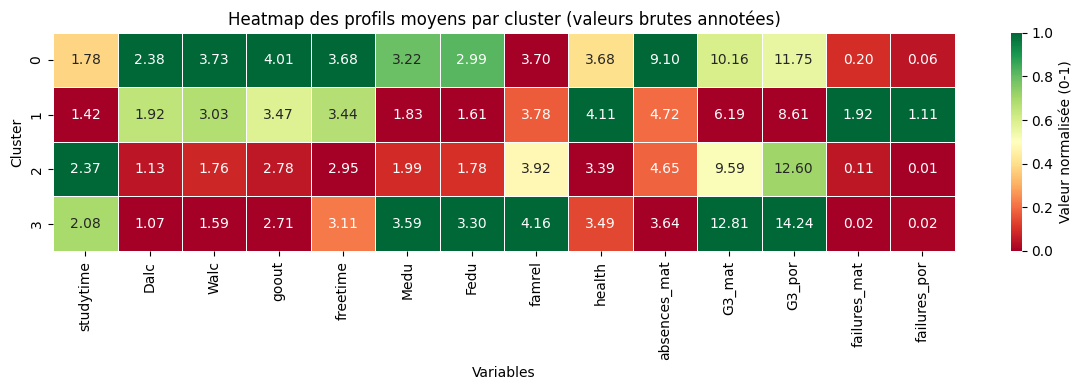

In [4]:
#Features retenues pour le clustering
features = [
    'studytime', 'Dalc', 'Walc', 'goout', 'freetime',
    'Medu', 'Fedu', 'famrel', 'health',
    'absences_mat', 'G3_mat', 'G3_por', 'failures_mat', 'failures_por'
]

# Stdardisation des données
df_km = merged[features].dropna().copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_km)

# Méthode du coude
inertia = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6, 4))

plt.plot(K_range, inertia, marker='o', color='#185FA5')

plt.title('Méthode du coude (Inertie)')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie')

plt.grid(alpha=0.3)

plt.show()

# Application du K-Means avec k optimal
k_optimal = 4

km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_km['cluster'] = km_final.fit_predict(X_scaled)

# Visualisation 2D via PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_km['pca1'] = X_pca[:, 0]
df_km['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
palette = {0: '#185FA5', 1: '#0F6E56', 2: '#A32D2D', 3: '#BA7517', 4: '#7F77DD'}
for c in sorted(df_km['cluster'].unique()):
    sub = df_km[df_km['cluster'] == c]
    plt.scatter(sub['pca1'], sub['pca2'], label=f'Cluster {c}',
                color=palette[c], alpha=0.6, s=40)
plt.title('Clusters K-Means projetés via PCA (2 composantes)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Profil moyen de chaque cluster
profile = df_km.groupby('cluster')[features].mean().round(2)
print("\nProfil moyen par cluster :")
print(profile.to_string())

# Heatmap du profil des clusters
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())  # normalisation 0-1
plt.figure(figsize=(12, 4))
sns.heatmap(profile_norm, annot=profile.values, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Valeur normalisée (0-1)'})
plt.title('Heatmap des profils moyens par cluster (valeurs brutes annotées)')
plt.xlabel('Variables')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [5]:
#variable avec laquelle on veut comparer nos clusters 
colonne_cible = 'Medu'

# on récupère les vraies étiquettes en s'assurant de garder les mêmes lignes que celles de df_km (après le dropna)
y_true = merged.loc[df_km.index, colonne_cible]

# on récupère les prédictions (les clusters générés par le K-Means)
y_pred = df_km['cluster']

# Calcul de l'indice de Rand (RI)
# L'indice de Rand varie de 0 à 1 (1 = correspondance parfaite)
ri = rand_score(y_true, y_pred)
print(f"Indice de Rand (RI) : {ri:.4f}")

# Calcul de l'indice de Rand Ajusté (ARI)
# L'ARI prend en compte le hasard. Il va de -1 à 1 (1 = parfaite, 0 = aléatoire, <0 = pire que l'aléatoire)
ari = adjusted_rand_score(y_true, y_pred)
print(f"Indice de Rand Ajusté (ARI) : {ari:.4f}")

Indice de Rand (RI) : 0.6834
Indice de Rand Ajusté (ARI) : 0.2087
